# 04 — More than one object

**Task 4:** simulate one object and several objects, and compare how well they can be detected,
told apart, and how their size and shape come out.

---

Notebook 03 showed a single object always reconstructs as a blob two to three times too big. That
immediately raises the question for this notebook: if each object is smeared out that much, how
close can two objects be before they merge into one?

In [1]:
import os, sys, time, warnings
from pathlib import Path

# Find pyEIT: either installed, or via the PYEIT_PATH environment variable.
try:
    import pyeit
except ImportError:
    for folder in filter(None, [os.environ.get("PYEIT_PATH"), "../pyEIT", "./pyEIT"]):
        if (Path(folder) / "pyeit").is_dir():
            sys.path.insert(0, str(Path(folder).resolve())); break
    import pyeit

sys.path.insert(0, str(Path.cwd()))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import eit_helpers as eit

eit.use_project_style()
figures = Path("figures"); figures.mkdir(exist_ok=True)
tables = Path("results"); tables.mkdir(exist_ok=True)

print(f"{eit.NUMBER_OF_ELECTRODES} electrodes, background conductivity "
      f"{eit.BACKGROUND_CONDUCTIVITY}, images {eit.IMAGE_SIZE}x{eit.IMAGE_SIZE}")

16 electrodes, background conductivity 1.0, images 64x64


In [2]:
fine_mesh, coarse_mesh = eit.build_meshes()
measurement_setup = eit.build_measurement_setup("adjacent")
OBJECT_RADIUS = 0.15
prepared = {method: eit.prepare_method(method, coarse_mesh, measurement_setup)[:2]
            for method in eit.METHODS}

def simulate(objects):
    """Simulate a set of objects and return the voltages and the true picture."""
    tank = eit.add_objects(fine_mesh, objects)
    background_voltages, object_voltages = eit.simulate_measurements(
        fine_mesh, tank, measurement_setup)
    return background_voltages, object_voltages, eit.true_picture(fine_mesh, tank)

def reconstruct_all(background_voltages, object_voltages):
    return {method: eit.reconstruct_image(method, coarse_mesh, measurement_setup,
                                          object_voltages, background_voltages,
                                          prepared_solver=prepared[method][0])
            for method in eit.METHODS}
print("ready")

ready


## One, two, three, four objects

All the objects are the same size and sit on a circle halfway out, evenly spaced, so they are all
equally visible and the only thing changing is how many there are.

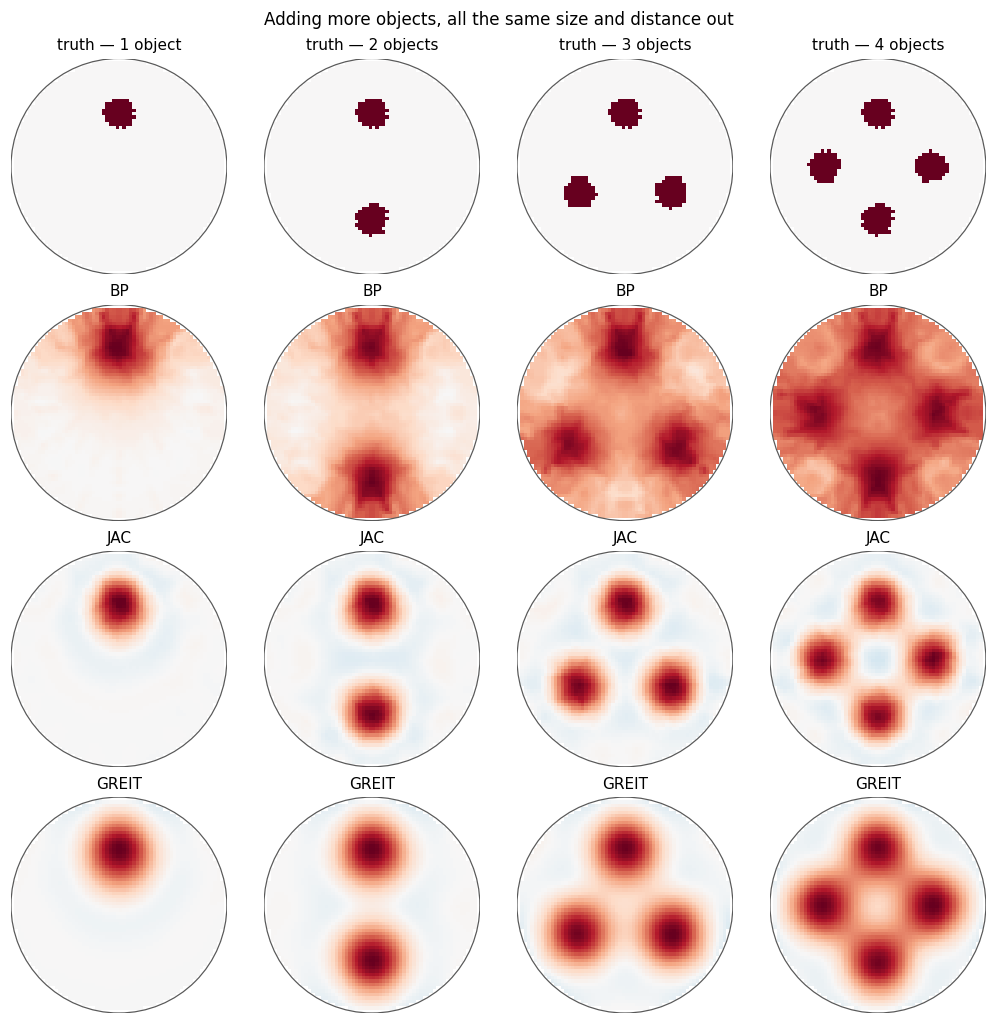

peak                          visibility                    
method back_projection gauss_newton  greit back_projection gauss_newton  greit
count                                                                         
1                0.034        0.330  0.193           3.134        6.783  5.200
2                0.036        0.331  0.193           2.299        4.758  3.718
3                0.035        0.336  0.190           2.204        3.938  3.007
4                0.038        0.347  0.186           2.138        3.390  2.407

In [3]:
def objects_on_a_ring(count, distance=0.5):
    angles = np.pi / 2 + np.arange(count) * 2 * np.pi / count
    return [{"centre": [distance * np.cos(angle), distance * np.sin(angle)],
             "radius": OBJECT_RADIUS, "conductivity": 2.0} for angle in angles]

counts = [1, 2, 3, 4]
count_rows = []

figure, axes = plt.subplots(len(eit.METHODS) + 1, len(counts),
                            figsize=(2.3 * len(counts), 2.3 * (len(eit.METHODS) + 1)),
                            constrained_layout=True)
for column, count in enumerate(counts):
    background_voltages, object_voltages, truth = simulate(objects_on_a_ring(count))
    eit.show_image(axes[0, column], truth,
                   title=f"truth — {count} object" + ("s" if count > 1 else ""))
    results = reconstruct_all(background_voltages, object_voltages)
    for row, method in enumerate(eit.METHODS, start=1):
        eit.show_image(axes[row, column], results[method].scaled,
                       title=eit.METHOD_SHORT[method])
        count_rows.append(dict(method=method, count=count,
                               peak=float(np.nanmax(np.abs(results[method].image))),
                               visibility=eit.contrast_to_noise(results[method].image, truth)))
figure.suptitle("Adding more objects, all the same size and distance out", fontsize=11)
figure.savefig(figures / "04_object_counts.png")
plt.show()

count_scores = pd.DataFrame(count_rows)
count_scores.to_csv(tables / "04_object_counts.csv", index=False)
count_scores.pivot(index="count", columns="method", values=["peak", "visibility"]).round(3)

All four objects show up in every case, which is the good news. But look at the **visibility**
column: it drops steadily as objects are added. The **peak** column explains why it is not a signal
problem — each object still reconstructs to roughly the same brightness. What changes is the
background: the faint halo around every object overlaps with all the others, so the tank stops
looking clean and each individual object becomes harder to pick out.

## How close can two objects get?

Two objects are moved gradually closer together and we watch for the point where the dip between
them disappears.

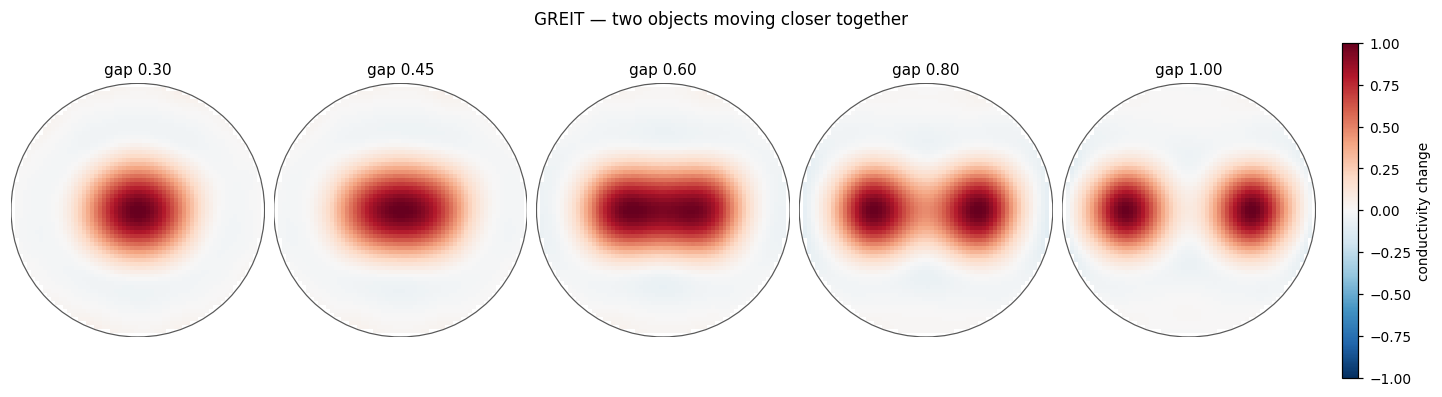

In [4]:
def dip_between_peaks(picture):
    """
    How deep the valley between the two blobs is, as a fraction of their height.
    1.0 means fully separated, 0 means they have merged into one blob.
    """
    profile = np.nan_to_num(picture[eit.IMAGE_SIZE // 2], nan=0.0)
    middle = eit.IMAGE_SIZE // 2
    left_peak = int(np.argmax(profile[:middle]))
    right_peak = int(np.argmax(profile[middle:])) + middle
    if right_peak <= left_peak:
        return 0.0
    peak_height = 0.5 * (profile[left_peak] + profile[right_peak])
    if peak_height <= 0:
        return np.nan
    valley = float(profile[left_peak:right_peak + 1].min())
    return float((peak_height - valley) / peak_height)

gaps = np.round(np.arange(0.30, 1.05, 0.05), 3)
shown_gaps = [0.30, 0.45, 0.60, 0.80, 1.00]

gap_rows, gallery = [], {method: [] for method in eit.METHODS}
for gap in gaps:
    two_objects = [{"centre": [-gap / 2, 0.0], "radius": OBJECT_RADIUS, "conductivity": 2.0},
                   {"centre": [+gap / 2, 0.0], "radius": OBJECT_RADIUS, "conductivity": 2.0}]
    background_voltages, object_voltages, truth = simulate(two_objects)
    results = reconstruct_all(background_voltages, object_voltages)
    for method in eit.METHODS:
        gap_rows.append(dict(method=method, gap=float(gap),
                             dip=dip_between_peaks(results[method].scaled)))
        if float(gap) in shown_gaps:
            gallery[method].append(results[method].scaled)

gap_scores = pd.DataFrame(gap_rows)
gap_scores.to_csv(tables / "04_separation.csv", index=False)

figure, _ = eit.show_images(gallery["greit"], [f"gap {gap:.2f}" for gap in shown_gaps],
                            heading="GREIT — two objects moving closer together")
figure.savefig(figures / "04_separation_greit.png")
plt.show()

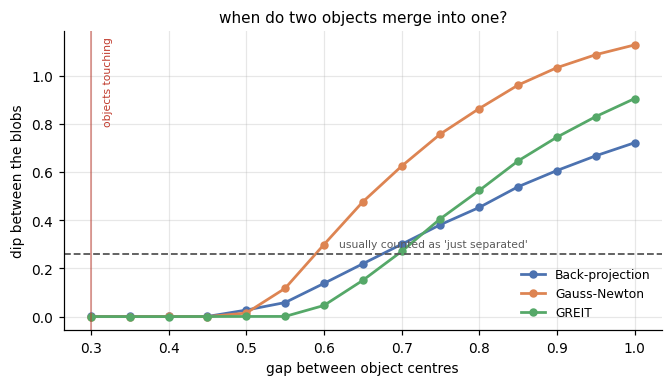

,method,smallest_gap,in_object_diameters
0,Back-projection,0.7,2.33
1,Gauss-Newton,0.6,2.00
2,GREIT,0.7,2.33


In [5]:
figure, axis = plt.subplots(figsize=(6, 3.4), constrained_layout=True)
for method in eit.METHODS:
    rows = gap_scores[gap_scores.method == method].sort_values("gap")
    axis.plot(rows.gap, rows.dip, marker="o", ms=4.5, lw=1.8,
              color=eit.METHOD_COLOURS[method], label=eit.METHOD_NAMES[method])
axis.axhline(0.26, ls="--", lw=1.2, color="0.35")
axis.annotate("usually counted as 'just separated'", xy=(0.62, 0.29), fontsize=7, color="0.35")
axis.axvline(2 * OBJECT_RADIUS, lw=1.0, color="#c0392b", alpha=0.6)
axis.annotate("objects touching", xy=(2 * OBJECT_RADIUS + 0.015, 0.8), fontsize=7,
              color="#c0392b", rotation=90)
axis.set_xlabel("gap between object centres"); axis.set_ylabel("dip between the blobs")
axis.set_title("when do two objects merge into one?")
axis.legend(fontsize=8); axis.grid(alpha=0.3)
figure.savefig(figures / "04_separation_curve.png")
plt.show()

closest = []
for method in eit.METHODS:
    rows = gap_scores[(gap_scores.method == method) & (gap_scores.dip >= 0.26)]
    smallest_gap = float(rows.gap.min()) if len(rows) else np.nan
    closest.append(dict(method=eit.METHOD_NAMES[method],
                        smallest_gap=smallest_gap,
                        in_object_diameters=round(smallest_gap / (2 * OBJECT_RADIUS), 2)))
closest_table = pd.DataFrame(closest)
closest_table.to_csv(tables / "04_closest_gap.csv", index=False)
closest_table

The objects physically touch at a gap of 0.30 (the red line), but the reconstructions merge long
before that. The table gives the smallest gap at which each method still shows two separate blobs —
roughly **twice the object diameter**, so there has to be a clear gap of about one whole object
between them before EIT can tell there are two.

## Mixing conductive and non-conductive objects

So far everything has been more conductive than the background. What if one object is more
conductive and the other less? The concern is that the false halo around a strong object looks like
an opposite-signed object, so this is worth checking.

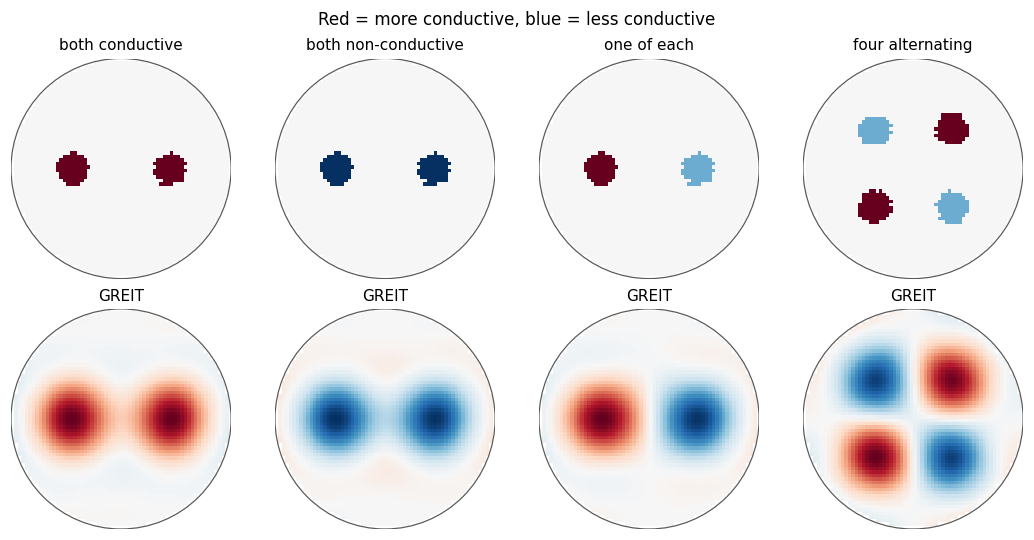

sign correct in every case: True


,configuration,object_conductivity,reconstructed_value,sign_correct
0,both conductive,2.0,0.960,True
1,both conductive,2.0,0.956,True
2,both non-conductive,0.5,-0.960,True
3,both non-conductive,0.5,-0.947,True
4,one of each,2.0,0.957,True
5,one of each,0.5,-0.940,True
6,four alternating,2.0,0.928,True
7,four alternating,0.5,-0.896,True
8,four alternating,2.0,0.957,True
9,four alternating,0.5,-0.892,True


In [6]:
mixtures = {
    "both conductive": [{"centre": [-0.45, 0], "radius": OBJECT_RADIUS, "conductivity": 2.0},
                        {"centre": [+0.45, 0], "radius": OBJECT_RADIUS, "conductivity": 2.0}],
    "both non-conductive": [{"centre": [-0.45, 0], "radius": OBJECT_RADIUS, "conductivity": 0.5},
                            {"centre": [+0.45, 0], "radius": OBJECT_RADIUS, "conductivity": 0.5}],
    "one of each": [{"centre": [-0.45, 0], "radius": OBJECT_RADIUS, "conductivity": 2.0},
                    {"centre": [+0.45, 0], "radius": OBJECT_RADIUS, "conductivity": 0.5}],
    "four alternating": [{"centre": [0.5 * np.cos(angle), 0.5 * np.sin(angle)],
                          "radius": OBJECT_RADIUS,
                          "conductivity": 2.0 if index % 2 == 0 else 0.5}
                         for index, angle in enumerate(np.arange(4) * np.pi / 2 + np.pi / 4)],
}

figure, axes = plt.subplots(2, len(mixtures),
                            figsize=(2.4 * len(mixtures), 4.8), constrained_layout=True)
mixture_rows = []
for column, (label, objects) in enumerate(mixtures.items()):
    background_voltages, object_voltages, truth = simulate(objects)
    eit.show_image(axes[0, column], truth, title=label)
    result = eit.reconstruct_image("greit", coarse_mesh, measurement_setup,
                                   object_voltages, background_voltages,
                                   prepared_solver=prepared["greit"][0])
    eit.show_image(axes[1, column], result.scaled, title="GREIT")

    for item in objects:                       # check the sign came out right
        centre_x, centre_y = item["centre"]
        column_index = int(round((centre_x + 1) / 2 * (eit.IMAGE_SIZE - 1)))
        row_index = int(round((centre_y + 1) / 2 * (eit.IMAGE_SIZE - 1)))
        value = float(np.nanmean(result.scaled[max(0, row_index - 2):row_index + 3,
                                               max(0, column_index - 2):column_index + 3]))
        mixture_rows.append(dict(configuration=label,
                                 object_conductivity=item["conductivity"],
                                 reconstructed_value=round(value, 3),
                                 sign_correct=(value > 0) == (item["conductivity"] > 1)))
figure.suptitle("Red = more conductive, blue = less conductive", fontsize=11)
figure.savefig(figures / "04_mixed.png")
plt.show()

mixture_table = pd.DataFrame(mixture_rows)
mixture_table.to_csv(tables / "04_mixed.csv", index=False)
print("sign correct in every case:", bool(mixture_table.sign_correct.all()))
mixture_table

Every object comes out with the right sign, and with a decent margin — the conductive ones clearly
red, the non-conductive ones clearly blue, even in the four-object case. Whether something is more
or less conductive than its surroundings is the most reliable thing an EIT difference image tells
you, much more so than its size.

## Does the reconstruction track the real size?

One object, varying its radius.

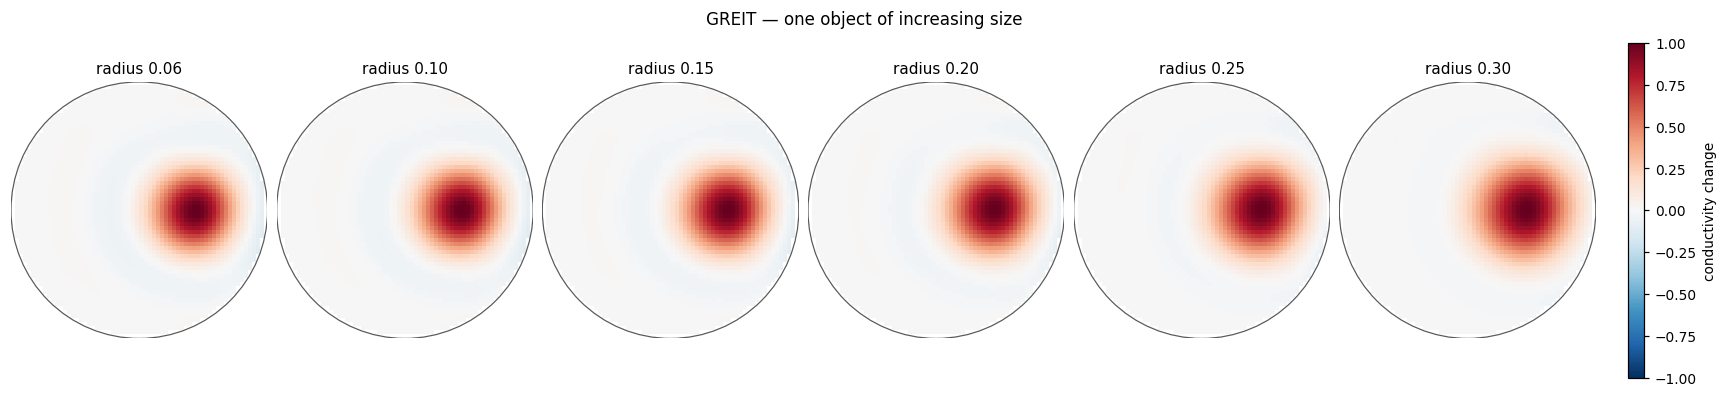

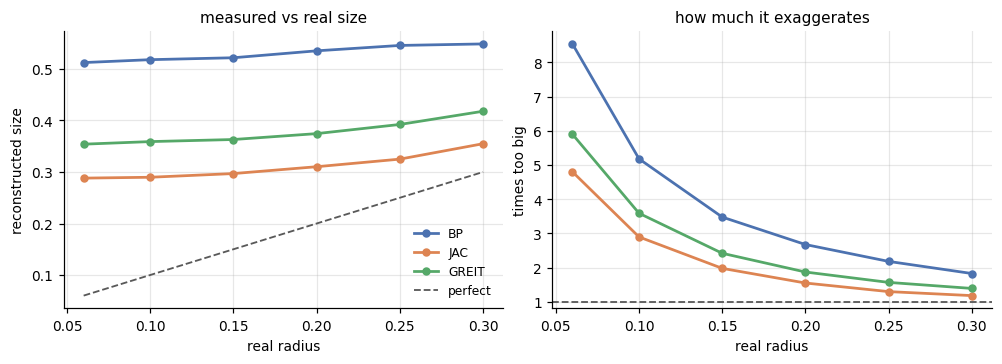

method,back_projection,gauss_newton,greit
real_radius,,,
0.06,8.54,4.80,5.90
0.10,5.18,2.90,3.59
0.15,3.48,1.98,2.42
0.20,2.68,1.55,1.87
0.25,2.18,1.30,1.57
0.30,1.83,1.18,1.39


In [7]:
real_radii = [0.06, 0.10, 0.15, 0.20, 0.25, 0.30]
size_rows, size_gallery = [], []
for radius in real_radii:
    background_voltages, object_voltages, truth = simulate(
        [{"centre": [0.45, 0.0], "radius": radius, "conductivity": 2.0}])
    results = reconstruct_all(background_voltages, object_voltages)
    size_gallery.append(results["greit"].scaled)
    for method in eit.METHODS:
        measured = eit.score_image(truth, results[method].image)["size"]
        size_rows.append(dict(method=method, real_radius=radius, measured_size=measured,
                              times_too_big=measured / radius))
size_scores = pd.DataFrame(size_rows)
size_scores.to_csv(tables / "04_sizes.csv", index=False)

figure, _ = eit.show_images(size_gallery, [f"radius {radius:.2f}" for radius in real_radii],
                            heading="GREIT — one object of increasing size")
figure.savefig(figures / "04_sizes.png")
plt.show()

figure, axes = plt.subplots(1, 2, figsize=(9, 3.2), constrained_layout=True)
for method in eit.METHODS:
    rows = size_scores[size_scores.method == method].sort_values("real_radius")
    axes[0].plot(rows.real_radius, rows.measured_size, marker="o", ms=4.5, lw=1.8,
                 color=eit.METHOD_COLOURS[method], label=eit.METHOD_SHORT[method])
    axes[1].plot(rows.real_radius, rows.times_too_big, marker="o", ms=4.5, lw=1.8,
                 color=eit.METHOD_COLOURS[method], label=eit.METHOD_SHORT[method])
axes[0].plot(real_radii, real_radii, ls="--", lw=1.2, color="0.35", label="perfect")
axes[1].axhline(1.0, ls="--", lw=1.2, color="0.35")
axes[0].set_xlabel("real radius"); axes[0].set_ylabel("reconstructed size")
axes[0].set_title("measured vs real size"); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[1].set_xlabel("real radius"); axes[1].set_ylabel("times too big")
axes[1].set_title("how much it exaggerates"); axes[1].grid(alpha=0.3)
figure.savefig(figures / "04_size_curves.png")
plt.show()

size_scores.pivot(index="real_radius", columns="method", values="times_too_big").round(2)

The measured size does go up with the real size, so it is not meaningless. But the exaggeration is
worst for the smallest objects and improves for big ones — small objects come out at roughly the
width of the blur rather than their own width. So the apparent size of a small object in an EIT
image tells you very little about how big it actually is.

---

## What I took away from this notebook

- Multiple objects all show up, but each one gets harder to pick out as more are added — not
  because the signal weakens, but because the halos around them clutter the background.
- Two objects merge into one blob once the gap between their centres drops below about twice their
  diameter.
- Conductive and non-conductive objects are never confused with each other. Sign is the most
  reliable information in the image.
- Reconstructed size follows real size but always overstates it, worst for small objects.

**Next:** [05 — current injection patterns](05_injection_patterns.ipynb)